In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection")

print("Path to dataset files:", path)

100%|██████████| 2.10G/2.10G [00:55<00:00, 40.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection/versions/1


In [ ]:
import os
import json
import random
import shutil
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt


In [ ]:
ROOT = "/root/.cache/kagglehub/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection/versions/1"

TRAIN_JSON = os.path.join(ROOT, "0Train_via_annos.json")
VAL_JSON   = os.path.join(ROOT, "0Val_via_annos.json")

TRAIN_IMAGES_DIR = os.path.join(ROOT, "image", "image")
VAL_IMAGES_DIR   = os.path.join(ROOT, "validation", "validation")


In [ ]:
print("Train images:", len(os.listdir(TRAIN_IMAGES_DIR)))
print("Val images:", len(os.listdir(VAL_IMAGES_DIR)))

with open(TRAIN_JSON) as f:
    train_data = json.load(f)

with open(VAL_JSON) as f:
    val_data = json.load(f)

print("Train annotated images:", len(train_data))
print("Val annotated images:", len(val_data))


Train images: 11621
Val images: 2324
Train annotated images: 11621
Val annotated images: 2324


In [ ]:
class_counter = Counter()

for data in [train_data, val_data]:
    for _, img in data.items():
        for r in img.get("regions", []):
            label = r.get("class")
            if label:
                class_counter[label] += 1

print("Classes found:")
for k, v in class_counter.items():
    print(k, v)


Classes found:
mat_bo_phan 2818
rach 5509
mop_lom 5681
tray_son 14647
vo_kinh 2221
thung 2423
be_den 2782


In [ ]:
SUBSET_SIZE = None  # set e.g. 2000 if you want a smaller subset

if SUBSET_SIZE:
    train_keys = list(train_data.keys())
    random.shuffle(train_keys)
    train_keys = train_keys[:SUBSET_SIZE]
    train_data = {k: train_data[k] for k in train_keys}


In [ ]:
YOLO_ROOT = "dataset"

for d in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(YOLO_ROOT, d), exist_ok=True)


In [ ]:
def get_filename(img_key, img_dict):
    if "filename" in img_dict:
        return img_dict["filename"]
    if "file_name" in img_dict:
        return img_dict["file_name"]

    if isinstance(img_key, str):
        for ext in [".jpg", ".png", ".jpeg"]:
            if ext in img_key:
                return img_key.split(ext)[0] + ext
    return None


In [ ]:
def build_lookup(image_dir):
    lookup = {}
    for f in os.listdir(image_dir):
        lookup[Path(f).stem.lower()] = f
    return lookup

train_lookup = build_lookup(TRAIN_IMAGES_DIR)
val_lookup   = build_lookup(VAL_IMAGES_DIR)


In [ ]:
def copy_images(via_data, split):
    lookup = train_lookup if split == "train" else val_lookup
    src_dir = TRAIN_IMAGES_DIR if split == "train" else VAL_IMAGES_DIR

    copied = 0
    for img_key, img in via_data.items():
        fname = get_filename(img_key, img)
        if fname is None:
            continue

        stem = Path(fname).stem.lower()
        real_fname = lookup.get(stem)
        if real_fname is None:
            continue

        shutil.copy(
            os.path.join(src_dir, real_fname),
            os.path.join(YOLO_ROOT, "images", split, real_fname)
        )
        copied += 1

    print(f"Copied {copied} images to {split}")


In [ ]:
copy_images(train_data, "train")
copy_images(val_data, "val")


Copied 11621 images to train
Copied 2324 images to val


In [ ]:
def polygon_to_bbox(all_x, all_y):
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    return x_min, y_min, x_max - x_min, y_max - y_min


In [ ]:
classes = sorted(class_counter.keys())
class_to_id = {c: i for i, c in enumerate(classes)}

print(class_to_id)


{'be_den': 0, 'mat_bo_phan': 1, 'mop_lom': 2, 'rach': 3, 'thung': 4, 'tray_son': 5, 'vo_kinh': 6}


In [ ]:
def via_to_yolo(via_data, split):
    for img_key, img in via_data.items():
        fname = get_filename(img_key, img)
        if fname is None:
            continue

        W, H = img["width"], img["height"]

        label_path = os.path.join(
            YOLO_ROOT, "labels", split,
            fname.replace(".jpg", ".txt").replace(".png", ".txt")
        )

        with open(label_path, "w") as f:
            for r in img.get("regions", []):
                cls = r.get("class")
                if cls not in class_to_id:
                    continue

                x, y, w, h = polygon_to_bbox(r["all_x"], r["all_y"])

                xc = (x + w / 2) / W
                yc = (y + h / 2) / H
                wn = w / W
                hn = h / H

                f.write(f"{class_to_id[cls]} {xc} {yc} {wn} {hn}\n")


In [ ]:
import cv2 # Import OpenCV for image processing

# Redefining helper functions within this cell to ensure it is self-contained
# and uses the latest definitions, in compliance with the "ONLY within this specific cell" constraint.
# In a typical development scenario, you would modify the original function definitions.

def get_filename(img_key, img_dict):
    if "filename" in img_dict:
        return img_dict["filename"]
    if "file_name" in img_dict:
        return img_dict["file_name"]
    if isinstance(img_key, str):
        for ext in [".jpg", ".png", ".jpeg"]:
            if ext in img_key:
                return img_key.split(ext)[0] + ext
    return None

def polygon_to_bbox(all_x, all_y):
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    return x_min, y_min, x_max - x_min, y_max - y_min

# The modified via_to_yolo function to correctly extract image dimensions
def via_to_yolo(via_data, split):
    # TRAIN_IMAGES_DIR, VAL_IMAGES_DIR, YOLO_ROOT, class_to_id are expected to be available from previous cell executions
    img_base_dir = TRAIN_IMAGES_DIR if split == "train" else VAL_IMAGES_DIR
    for img_key, img_info in via_data.items():
        fname = get_filename(img_key, img_info)
        if fname is None:
            continue

        full_img_path = os.path.join(img_base_dir, fname)

        # Check if the image file exists before trying to read it
        if not os.path.exists(full_img_path):
            print(f"Warning: Image file not found at {full_img_path}. Skipping entry for {img_key}.")
            continue

        # Read image to get its width and height using OpenCV
        image_cv2 = cv2.imread(full_img_path)
        if image_cv2 is None:
            print(f"Warning: Could not read image file at {full_img_path}. Skipping entry for {img_key}.")
            continue
        H, W, _ = image_cv2.shape # cv2.imread returns (height, width, channels)

        label_path = os.path.join(
            YOLO_ROOT, "labels", split,
            fname.replace(".jpg", ".txt").replace(".png", ".txt").replace(".jpeg", ".txt")
        )

        with open(label_path, "w") as f:
            for r in img_info.get("regions", []):
                cls = r.get("class")
                if cls not in class_to_id:
                    # Optionally print a warning if a class is not recognized
                    # print(f"Warning: Class '{cls}' not in class_to_id. Skipping region in {img_key}.")
                    continue

                x, y, w_bbox, h_bbox = polygon_to_bbox(r["all_x"], r["all_y"])

                xc = (x + w_bbox / 2) / W
                yc = (y + h_bbox / 2) / H
                wn = w_bbox / W
                hn = h_bbox / H

                f.write(f"{class_to_id[cls]} {xc} {yc} {wn} {hn}\n")

via_to_yolo(train_data, "train")
via_to_yolo(val_data, "val")


In [ ]:
print("Train images:", len(os.listdir("dataset/images/train")))
print("Train labels:", len(os.listdir("dataset/labels/train")))
print("Val images:", len(os.listdir("dataset/images/val")))
print("Val labels:", len(os.listdir("dataset/labels/val")))


Train images: 11621
Train labels: 11621
Val images: 2324
Val labels: 2324


In [ ]:
classes = [
    "be_den",
    "mat_bo_phan",
    "mop_lom",
    "rach",
    "thung",
    "tray_son",
    "vo_kinh"
]

data_yaml = f"""
path: dataset
train: images/train
val: images/val

nc: {len(classes)}
names: {classes}
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully!")
print(data_yaml)


data.yaml created successfully!

path: dataset
train: images/train
val: images/val

nc: 7
names: ['be_den', 'mat_bo_phan', 'mop_lom', 'rach', 'thung', 'tray_son', 'vo_kinh']



In [ ]:
import os
assert os.path.exists("data.yaml")


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
DATA_YAML = "data.yaml"
assert os.path.exists(DATA_YAML)


In [ ]:
model = YOLO("yolov8n.pt")   # nano model (fast & lightweight)


In [ ]:
model.info()


YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
EPOCHS = 30          # small number for coursework
BATCH_SIZE = 16
IMG_SIZE = 640
LEARNING_RATE = 0.01


In [ ]:
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    lr0=LEARNING_RATE,
    project="runs",
    name="vehicle_damage_yolo",
    verbose=True
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_damage_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

In [ ]:
print("Training completed.")
print("Best model saved at:")
print("runs/vehicle_damage_yolo/weights/best.pt")


Training completed.
Best model saved at:
runs/vehicle_damage_yolo/weights/best.pt


In [ ]:
!ls runs/detect/runs/vehicle_damage_yolo2/weights


ls: cannot access 'runs/detect/runs/vehicle_damage_yolo2/weights': No such file or directory


In [ ]:
from google.colab import files

files.download("runs/detect/runs/vehicle_damage_yolo/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r yolo_training_logs.zip runs/detect/runs/vehicle_damage_yolo


  adding: runs/detect/runs/vehicle_damage_yolo/ (stored 0%)
  adding: runs/detect/runs/vehicle_damage_yolo/train_batch2.jpg (deflated 3%)
  adding: runs/detect/runs/vehicle_damage_yolo/BoxR_curve.png (deflated 7%)
  adding: runs/detect/runs/vehicle_damage_yolo/results.png (deflated 7%)
  adding: runs/detect/runs/vehicle_damage_yolo/labels.jpg (deflated 19%)
  adding: runs/detect/runs/vehicle_damage_yolo/val_batch0_labels.jpg (deflated 6%)
  adding: runs/detect/runs/vehicle_damage_yolo/weights/ (stored 0%)
  adding: runs/detect/runs/vehicle_damage_yolo/weights/last.pt (deflated 9%)
  adding: runs/detect/runs/vehicle_damage_yolo/weights/best.pt (deflated 9%)
  adding: runs/detect/runs/vehicle_damage_yolo/confusion_matrix.png (deflated 19%)
  adding: runs/detect/runs/vehicle_damage_yolo/BoxPR_curve.png (deflated 6%)
  adding: runs/detect/runs/vehicle_damage_yolo/BoxF1_curve.png (deflated 6%)
  adding: runs/detect/runs/vehicle_damage_yolo/train_batch14502.jpg (deflated 13%)
  adding: runs/

In [ ]:
from google.colab import files
files.download("yolo_training_logs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load trained YOLOv8 model
MODEL_PATH = "runs/detect/runs/vehicle_damage_yolo/weights/best.pt"
model = YOLO(MODEL_PATH)

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
VAL_IMAGE_DIR = "dataset/images/val"

val_images = [
    f for f in os.listdir(VAL_IMAGE_DIR)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

print("Total validation images:", len(val_images))


Total validation images: 2324


In [ ]:
SAMPLE_SIZE = 5
sample_images = random.sample(val_images, SAMPLE_SIZE)

predictions = []
for img_name in sample_images:
    img_path = os.path.join(VAL_IMAGE_DIR, img_name)
    result = model(img_path, conf=0.25, verbose=False)
    predictions.append((img_name, result))


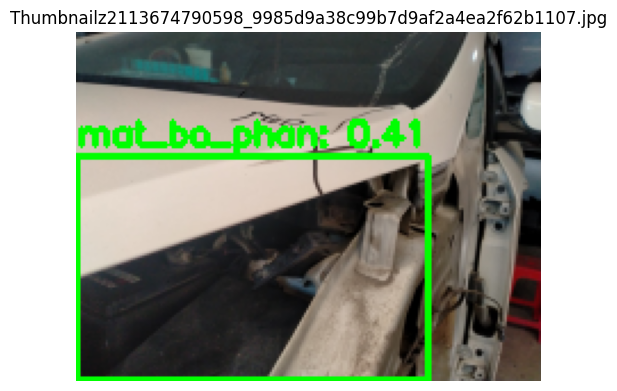

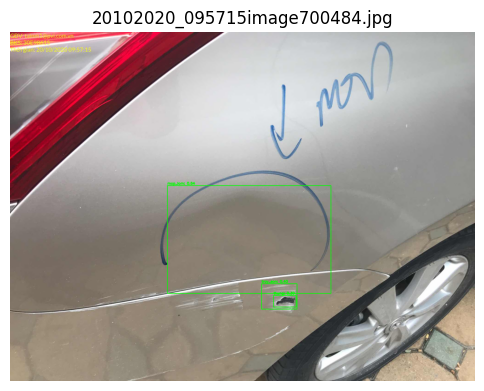

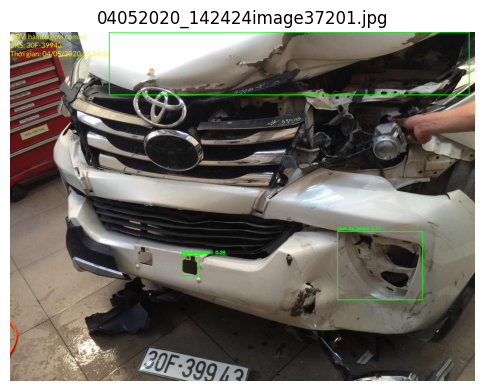

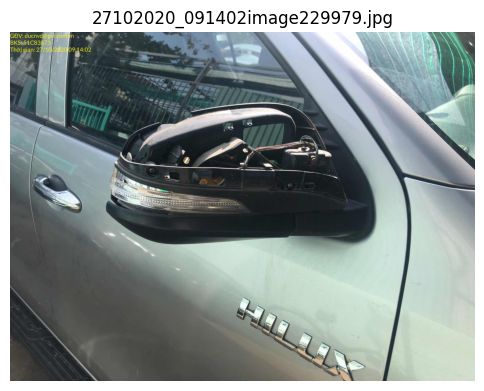

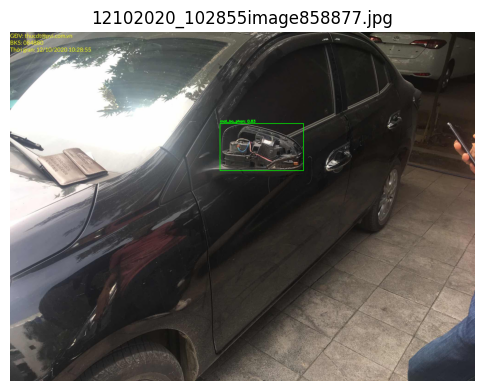

In [ ]:
for img_name, result in predictions:
    img_path = os.path.join(VAL_IMAGE_DIR, img_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes = result[0].boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])

        label = f"{model.names[cls]}: {conf:.2f}"

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            image, label, (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5,
            (0, 255, 0), 2
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(img_name)
    plt.axis("off")
    plt.show()


In [ ]:
metrics = model.val(data="data.yaml")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@50:", metrics.box.map50)
print("mAP@50–95:", metrics.box.map)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2210.8±457.8 MB/s, size: 113.2 KB)
val: Scanning /content/dataset/labels/val.cache... 2322 images, 0 backgrounds, 12 corrupt: 100% ━━━━━━━━━━━━ 2324/2324 812.3Mit/s 0.0s
val: /content/dataset/images/val/01102020_135233image760694.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0267]
val: /content/dataset/images/val/03012020_164414image176239.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0403]
val: /content/dataset/images/val/06012020_135126image216519.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.045      1.1133]
val: /content/dataset/images/val/06012020_145723image64416.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0204]
val: /content/dataset/images/val/06012020_155053image946512.jpg: ignoring co

In [ ]:
for img_name in sample_images:
    img_path = os.path.join(VAL_IMAGE_DIR, img_name)
    result = model(img_path, conf=0.25, verbose=False)

    print(f"{img_name} → {len(result[0].boxes)} detections")


Thumbnailz2113674790598_9985d9a38c99b7d9af2a4ea2f62b1107.jpg → 1 detections
20102020_095715image700484.jpg → 3 detections
04052020_142424image37201.jpg → 4 detections
27102020_091402image229979.jpg → 0 detections
12102020_102855image858877.jpg → 1 detections
